Loading base packages

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np

SEED = 0 # Random hyperparameter

### Loading data

In [2]:
df = pd.read_csv('g20_exportdata_2018.csv', encoding='latin1')

Data reduction keeping only important variables

In [3]:
col = [
'refPeriodId',      # Period ID
'refYear',           # Reference Year
'refMonth',          # Reference Month
'reporterCode',      # Reporter (exporter) code
'reporterISO',       # Reporter (exporter) name
'flowCode',          # Type of flow (export)
'partnerCode',       # Partner (importer) code
'partnerISO',        # Partner (importer) name
'isOriginalClassification', # Export classification (TOTAL)
'cmdCode',           # Export type (commodities)
'cifvalue',          # Export value + transportation costs
'fobvalue',          # Export value (on board)
]

df = df[col]

We use `fobvalue` as it excludes transportation costs. `cifvalue` will instead be used to evaluate the goodness of our assumption regarding cost/distance parameters.

In [4]:
df['reporterCode'].value_counts() # checking whether all nations have data available for every partner

reporterCode
ARG    18
AUS    18
BRA    18
CAN    18
CHN    18
FRA    18
DEU    18
IDN    18
ITA    18
JPN    18
KOR    18
MEX    18
RUS    18
SAU    18
IND    18
ZAF    18
TUR    18
GBR    18
USA    18
Name: count, dtype: int64

Data scaling (reducing by a factor of $10^3$) for greater computational easeness 

In [8]:
df[['cifvalue', 'fobvalue']] = df[['cifvalue', 'fobvalue']] / 1e6

### Trade flow graph

In [9]:
# Trade graph showing trade relations
G_trade = nx.from_pandas_edgelist(
    df, source='reporterCode', target='partnerCode', edge_attr='fobvalue',  create_using=nx.DiGraph()
)

Plotting

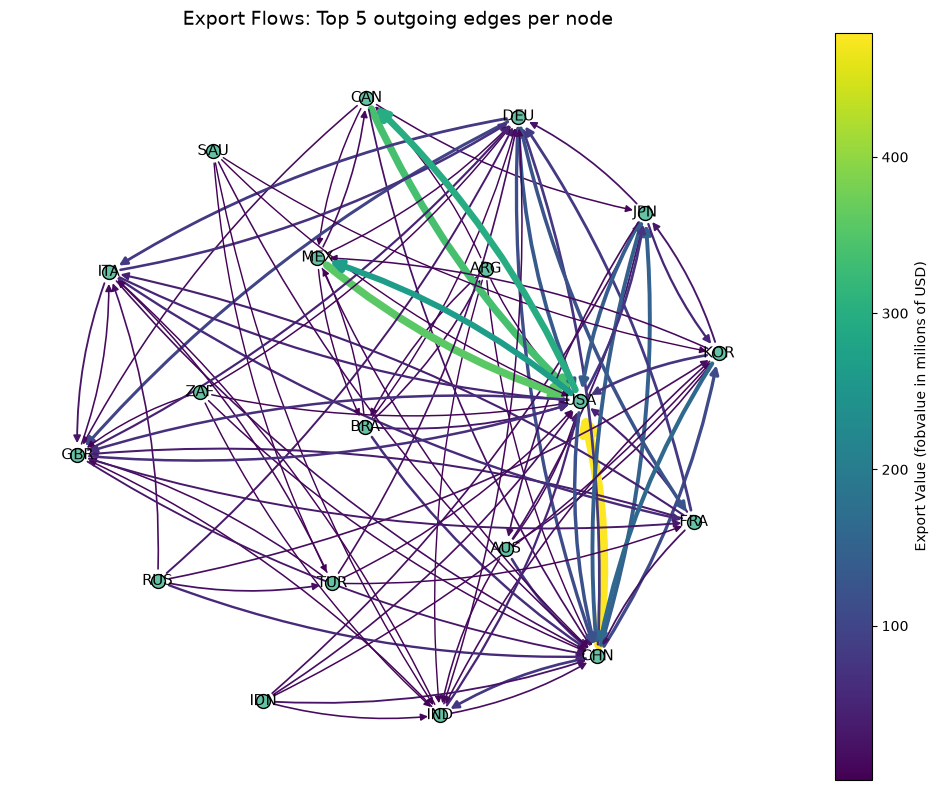

In [12]:
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G_trade, k=1, seed=SEED)

# --- Filter only top 5 export partner for each reporter ---
edgelist_to_draw = []
w = []

# Sorting of nodes according to 'fobvalue' values
for node, neighbors in G_trade.adjacency():
    # 'neighbors' dictionary with: {neighbors: {'fobvalue': value, ...}}
    # we sort neighbors on 'fobvalue' in decreasing order
    top_5 = sorted(
        neighbors.items(),
        key=lambda item: item[1].get('fobvalue', 0),
        reverse=True,
    )[:5]
# Top 5 extraction
    for neighbor, edge_data in top_5:
        edgelist_to_draw.append((node, neighbor))
        w.append(edge_data.get('fobvalue', 0))

# Normalization of arrows and thickness
if len(w) > 0:
    min_val, max_val = min(w), max(w)

    if min_val == max_val:
        arrow_sizes = [30] * len(w)
        edge_widths = [3] * len(w)
    else:
        # Arrow
        min_arrow, max_arrow = 10, 20
        arrow_sizes = [
            ((v - min_val) / (max_val - min_val)) * (max_arrow - min_arrow)
            + min_arrow
            for v in w
        ]

        # B Line thickness
        min_width, max_width = 1, 7
        edge_widths = [
            ((v - min_val) / (max_val - min_val)) * (max_width - min_width)
            + min_width
            for v in w
        ]
else:
    arrow_sizes, edge_widths = [], []
    min_val, max_val = 0, 1

# Plot
nx.draw_networkx_nodes(
    G_trade, pos, ax=ax, node_color='#66c2a5', node_size=100, edgecolors='black'
)
nx.draw_networkx_labels(
    G_trade, pos, ax=ax, font_size=11, font_family='sans-serif'
)

edges = nx.draw_networkx_edges(
    G_trade,
    pos,
    ax=ax,
    edgelist=edgelist_to_draw,
    edge_color=w,
    edge_cmap=plt.cm.viridis,
    width=edge_widths,
    arrowsize=arrow_sizes,
    connectionstyle='arc3,rad=0.1',
)

# Colorbar 
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis, norm=plt.Normalize(vmin=min_val, vmax=max_val)
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Export Value (fobvalue in milions of USD)')

plt.title(
    'Export Flows: Top 5 outgoing edges per node',
    fontsize=14,
)
plt.axis('off')
plt.tight_layout()
plt.show()

# World Graph Creation

We create a graph resembling the actual world structure. Meaning that edges will indicate that two points are contiguous on the world map

### Data fetching

In [91]:
import geopandas as gpd
from shapely.geometry import MultiPolygon, box, Point
url = "./countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file('countries')

# Selection of G20 nations
nations = ['Argentina','Australia','Brazil','Canada','China','France','Germany','India','Indonesia','Italy','Japan','Mexico','Russia','Saudi Arabia','South Africa','South Korea','Turkey','United Kingdom','United States of America']
g20 = world[world['NAME'].isin(nations)]

# Creation of Sea Boxes
seas_geometry = {
    'NAME': ['North Atlantic Ocean','South Atlantic Ocean', 'Mediterranean Sea', 'Black Sea', 'Baltic Sea', 'Norwegian/Barents Sea', 'Arabic Sea', 'Gulf of Bengal', 'West Indian Ocean', 'Indian Ocean', 'South/North Chinese Sea', 'Japanese Sea', 'Banda Sea', 'East Pacific Ocean', 'West Pacific Ocean', 'Caribbean Sea'],
    'geometry':[
        # 1. North Atlantic Ocean
        box(-80.0, 0.0, 0.0, 65.0),
        # 2. South Atlantic Ocean
        box(-70.0, -60.0, 20.0, 0.0),
        # 3. Mediterranean Sea
        box(-6.0, 30.0, 36.0, 46.0),
        # 4. Black Sea
        box(27.0, 40.5, 42.0, 47.0),
        # 5. Baltic Sea
        box(9.5, 53.5, 30.0, 66.0),
        # 6. Norwegian/Barents Sea
        box(-10.0, 62.0, 60.0, 80.0),
        # 7. Arabic Sea
        box(45.0, 0.0, 77.0, 25.0),
        # 8. Gulf of Bengal
        box(77.0, 5.0, 98.0, 23.0),
        # 9. West Indian Ocean (East Africa Coast and Madagascar)
        box(30.0, -35.0, 60.0, 12.0),
        # 10. Indian Ocean 
        box(60.0, -60.0, 115.0, 0.0),
        # 11. South/North Chinese Sea
        box(100.0, 0.0, 130.0, 40.0),
        # 12. Japanese Sea
        box(127.0, 34.0, 142.0, 52.0),
        # 13. Banda Sea
        box(124.0, -8.0, 132.0, -3.0),
        # 14. Pacific Ocean (Split in two beacuse of the 180 Meridian)
        box(130.0, -50.0, 180.0, 65.0),  # East
        box(-180.0, -50.0, -70.0, 65.0),  # West
        # 15. Caribbean Sea
        box(-88.0, 9.0, -60.0, 22.0),
    ],
}

seas = gpd.GeoDataFrame(seas_geometry, crs="EPSG:4326")

# Creation of Straits/Canals data
canal_geom = {
    'NAME' : ['Kiel', 'Gibiltrair', 'Suez', 'Dardanelles', 'Malacca', 'Magellan', 'Panama','Good Hope'],
    'geometry' : [
        Point(9.53, 54.36),   # Kiel Canal
        Point(-5.35, 35.98),  # Gibiltrair
        Point(32.34, 30.58),  # Suez Canal
        Point(26.40, 40.20),  # Dardanelles
        Point(101.50, 2.50),  # Malacca Strait
        Point(-70.90, -53.60),# Magellan Strait
        Point(-79.68, 9.08),  # Panama Canal
        Point(18.16,-34.12)   # Good Hope  
    ]
}

canals = gpd.GeoDataFrame(canal_geom, crs="EPSG:4326" )

### Graph generation

In [92]:
# Integrated Graph Creation
G = nx.Graph()

# Nations Nodes
for idx, row in g20.iterrows():
    G.add_node(
        row["NAME"],
        node_type="country",
        pos=(row["geometry"].centroid.x, row["geometry"].centroid.y),
    )

# Seas Nodes
for idx, row in seas.iterrows():
    G.add_node(
        row["NAME"],
        node_type="sea",
        pos=(row["geometry"].centroid.x, row["geometry"].centroid.y),
    )

# Canal Nodes
for idx, row in canals.iterrows():
    G.add_node(
        row['NAME'],
        node_type='canal/strait',
        pos=(row['geometry'].x, row['geometry'].y)
    )

# Adjusting non representative centroids for particular cases
pos = nx.get_node_attributes(G, "pos")
custom_positions = {
    "Canada" : (-80, 47.5),
    #"China" : (30, 120),
    "United States of America": (-100.0369, 38.9072),
    "France": (2.3522, 46.8566),
    "Russia": (37.6173, 55.7558),
}
# Updating personalized positions
for node, new_coords in custom_positions.items():
    if node in G:
        pos[node] = new_coords
        G.nodes[node]["pos"] = new_coords

# Country-country Edges
geoms_countries = g20["geometry"].values
names_countries = g20["NAME"].values
for i in range(len(g20)):
    for j in range(i + 1, len(g20)):
        if geoms_countries[i].touches(geoms_countries[j]):
            G.add_edge(names_countries[i], names_countries[j], edge_type="land")
# Country-sea Edges (Accesso Marittimo Nazione -> Mare)
for _, country in g20.iterrows():
    for _, sea in seas.iterrows():
        if country["geometry"].buffer(0.1).intersects(sea["geometry"]):
            G.add_edge(
                country["NAME"], sea["NAME"], edge_type="maritime_access"
            )
# Sea-sea Edges (Connessioni Dirette Mare -> Mare)
for i in range(len(seas)):
    for j in range(i + 1, len(seas)):
        if seas.iloc[i]["geometry"].intersects(seas.iloc[j]["geometry"]):
            G.add_edge(
                seas.iloc[i]["NAME"],
                seas.iloc[j]["NAME"],
                edge_type="sea_strait",
            )
# Canal/Strait-Sea Edges (Connessioni Stretto -> Mare Adiacente)
# Si applica un buffer di 1.0° al punto dello stretto per intercettare i mari confinanti
for _, canal in canals.iterrows():
    canal_buffer = canal["geometry"].buffer(1.0)
    for _, sea in seas.iterrows():
        if canal_buffer.intersects(sea["geometry"]):
            G.add_edge(canal["NAME"], sea["NAME"], edge_type="sea_strait")

print(
    f"Mixed Graph Created: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges."
)

Mixed Graph Created: 43 Nodes, 83 Edges.


### Edge manipolation

Printing the edgelist


In [93]:
df_edges = nx.to_pandas_edgelist(G)

Some edges need to be removed (i.e. France-Brazil land border), others need to be added (i.e. Arabic sea-Mediterranean link)

In [94]:
# TODO correggi mancanze di edge

# West pacific
remove = ['Caribbean Sea', 'North Atlantic Ocean', 'South Atlantic Ocean', 'Brazil', 'Russia']
for e in remove:
    if G.has_edge('West Pacific Ocean', e):
        G.remove_edge('West Pacific Ocean', e)

G.add_edge('West Pacific Ocean','Magellan', edge_type='sea_strait')

# Caribbean Sea
G.add_edge('United States of America', 'Caribbean Sea', edge_type='maritime_access')

# Panama
if G.has_edge('Panama','North Atlantic Ocean'):
    G.remove_edge('Panama','North Atlantic Ocean')

# Brazil
# removing land border with France (technically exists but not really relevant trade-wise)
if G.has_edge('Brazil', 'France'):
    G.remove_edge('Brazil', 'France')

# Mediterranean Sea
remove = ['Russia','North Atlantic Ocean','Black Sea']
for e in remove:
    if G.has_edge('Mediterranean Sea', e):
        G.remove_edge('Mediterranean Sea', e)

# Baltic Sea
if G.has_edge('Baltic Sea','Norwegian/Barents Sea'):
    G.remove_edge('Baltic Sea','Norwegian/Barents Sea')

# Linking Straits to Seas
G.add_edge('Kiel', 'North Atlantic Ocean', edge_type='sea_strait')
G.add_edge('Suez', 'Arabic Sea', edge_type='sea_strait')

# China
remove = ['Japanese Sea', 'East Pacific Ocean']
for e in remove:
    if G.has_edge('China', e):
        G.remove_edge('China', e)

# Indian Ocean
if G.has_edge('Indian Ocean', 'South/North Chinese Sea'):
    G.remove_edge('Indian Ocean', 'South/North Chinese Sea')

# Pacific Link
G.add_edge('West Pacific Ocean','East Pacific Ocean', edge_type='sea_strait')

# Malacca and Banda Sea
add = ['Gulf of Bengal', 'Banda Sea']
for e in add:
    G.add_edge('Malacca', e, edge_type='sea_strait')
G.add_edge('Banda Sea','Indian Ocean', edge_type='sea_strait')

# Good Hope Atlantic-Indian Linking
G.add_edge('Good Hope', 'West Indian Ocean', edge_type='sea_strait')

### Visualization

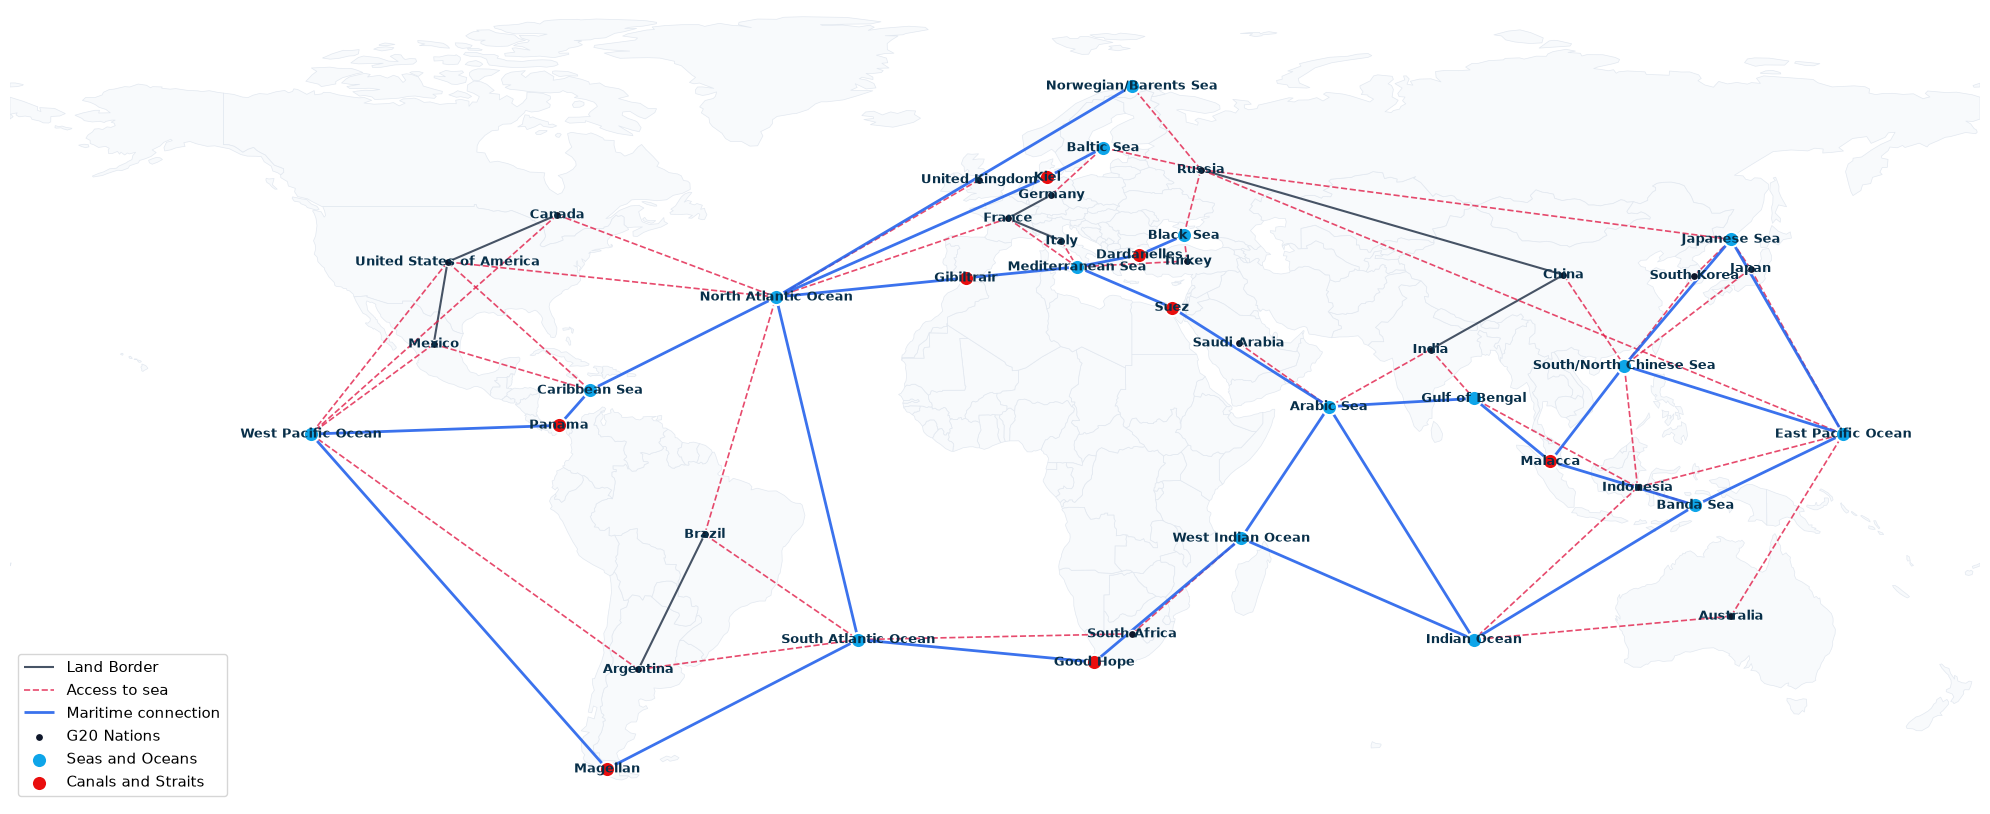

In [ ]:

land_nodes = [n for n in G.nodes() if n in world["NAME"].values]
sea_nodes = [n for n in G.nodes() if n not in land_nodes]

# --- WORLD MAP AND HIGHLIGHTS ---
world.plot(ax=ax, color="#f8fafc", edgecolor="#e2e8f0", linewidth=0.5, zorder=1)

highlighted_nations = world[world["NAME"].isin(land_nodes)]
if not highlighted_nations.empty:
    highlighted_nations.plot(ax=ax, color="#cbd5e1", edgecolor="#64748b", linewidth=0.8, zorder=2)
else:
    print("No highlighted nation in the daataset")

fig, ax = plt.subplots(figsize=(20, 10))

# --- NODES ---
land_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "country"]
sea_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "sea"]
strait_nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == "canal/strait"]



world.plot(ax=ax, color="#f8fafc", edgecolor="#e2e8f0", linewidth=0.5, zorder=1)

# Highlighting only selected nations
highlighted_nations = world[world["NAME"].isin(land_nodes)]
not_highlighted_nations = world[~world["NAME"].isin(land_nodes)]
highlighted_nations.plot(ax=ax, color="#7badeb", edgecolor="#64748b", linewidth=0.8, zorder=2)
not_highlighted_nations.plot(ax=ax, color="#cfdbe9", edgecolor="#64748b", linewidth=0.8, zorder=2)


# --- NODE POSITIONS AND EDGES DISCRIMINATION ---
pos = nx.get_node_attributes(G, "pos")

land_land_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "land"]
land_sea_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "maritime_access"]
sea_sea_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "sea_strait" and {u, v} != {"West Pacific Ocean", "East Pacific Ocean"}]

# --- DISEGNO ARCHI ---
nx.draw_networkx_edges(
    G, pos, edgelist=land_land_edges, ax=ax,
    edge_color="#334155", width=1.5, alpha=0.9, label="Land Border"
)
nx.draw_networkx_edges(
    G, pos, edgelist=land_sea_edges, ax=ax,
    edge_color="#e11d48", width=1.2, alpha=0.8, style="dashed", label="Access to sea"
)
nx.draw_networkx_edges(
    G, pos, edgelist=sea_sea_edges, ax=ax,
    edge_color="#2563eb", width=2.0, alpha=0.9, label="Maritime connection"
)

# --- DISEGNO NODI ---
# Nodi terrestri
nx.draw_networkx_nodes(
    G, pos, nodelist=land_nodes, ax=ax,
    node_size=35, node_color="#0f172a", edgecolors="white", linewidths=1, label="G20 Nations"
)
# Nodi marittimi (Centri geografici dei mari)
nx.draw_networkx_nodes(
    G, pos, nodelist=sea_nodes, ax=ax,
    node_size=120, node_color="#0ea5e9", edgecolors="white", linewidths=1.5, label="Seas and Oceans"
)
# Strait nodes
nx.draw_networkx_nodes(
    G, pos, nodelist=strait_nodes, ax=ax,
    node_size=120, node_color="#e90e0e", edgecolors="white", linewidths=1.5, label="Canals and Straits"
)

# --- SEA LABELS ---
land_labels = {n: n for n in land_nodes}
nx.draw_networkx_labels(
    G, pos, labels=land_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)
sea_labels = {n: n for n in sea_nodes}
nx.draw_networkx_labels(
    G, pos, labels=sea_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)
strait_labels = {n: n for n in strait_nodes}
nx.draw_networkx_labels(
    G, pos, labels=strait_labels, ax=ax, 
    font_size=9, font_weight="bold", font_color="#082f49"
)

# --- FINAL PLOT SETTING ---
plt.title(
    "",
    fontsize=16,
    fontweight="bold",
)
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.xlim(-180, 180)
plt.ylim(-60, 85)
plt.axis("off")
plt.tight_layout()
plt.show()